In [1]:
import numpy as np
import torch
import geoopt

In [ ]:

def manifold_gaussian_pdf(x, mean, std, manifold):
    """
    Compute the probability density of a point x under a manifold Gaussian.
    """
    d = manifold.dist(torch.tensor(x), mean)  # Compute manifold distance
    return np.exp(-d**2 / (2 * std**2))  # Gaussian decay in manifold space

def sample_manifold_gaussian(n_samples, mean, variance, manifold, max_attempts=50000):
    """
    Sample from a manifold Gaussian using rejection sampling.
    
    Parameters:
    - n_samples (int): Number of points to sample.
    - mean (np.ndarray): Mean point in the manifold (shape: (2,))
    - std (float): Standard deviation in manifold space.
    - max_attempts (int): Maximum number of attempts before giving up.

    Returns:
    - np.ndarray: Sampled points in the manifold (shape: (n_samples, 2)).
    """
    samples = []
    attempts = 0
    
    while len(samples) < n_samples and attempts < max_attempts:
        # Propose a random point in the manifold
        radius = np.random.uniform(0,1/np.sqrt(np.abs(manifold.k)))
        theta = np.random.uniform(0, 2*np.pi)
        x = radius*np.array([np.cos(theta), np.sin(theta)])

        # Compute acceptance probability
        prob = manifold_gaussian_pdf(x, mean, variance,manifold)
        threshold = np.random.uniform(0, 1)  # Random uniform value

        if prob > threshold:  # Accept if it follows the Gaussian distribution
            samples.append(x)

        attempts += 1

    if len(samples) < n_samples:
        print("Warning: Could not generate enough points within max_attempts.")

    return torch.tensor(samples)

In [10]:

# Define the manifold manifold (Poincaré Ball)
manifold = geoopt.PoincareBall(c=1)  # Curvature c=1
radius = manifold.radius
# Step 1: Sample 4 centroids from a zero-mean manifold Gaussian (variance 1.5)
mean_zero = torch.zeros(2)  # Center at origin
centroid_var = 1 * radius.numpy()  
n_centroids = 4 
centroids = sample_manifold_gaussian(n_samples=n_centroids, mean=mean_zero, variance=centroid_var, manifold=manifold)

# Step 2: Sample 100 points around each centroid (unit variance)
dataset = []
tan_dataset = []
labels = []
c_labels =[]
num_sampels = 100

# Variable variance for each cluster 
var_percents = np.random.uniform(0.15, 0.5, n_centroids) 

# Define the variance according to the radius of the space for realistic clusters
vars = var_percents * radius.numpy()
for i, centroid in enumerate(centroids):
    points = sample_manifold_gaussian(n_samples=num_sampels, mean=centroid, variance=vars[i], manifold=manifold)
    dataset.append(points)
    # tan_dataset.append(manifold.logmap(points, centroid)+manifold.logmap0(centroid))
    tan_dataset.append(manifold.logmap0(points))

    
    labels.extend([i] * len(points))  # Assign class labels
    c_labels.append(i)

# Convert to NumPy
dataset = torch.cat(dataset).numpy()
tan_dataset = torch.cat(tan_dataset).numpy()
labels = np.array(labels)

tan_centroids = manifold.logmap0(centroids)


In [4]:
import matplotlib.pyplot as plt

color_map = plt.cm.get_cmap('viridis', len(centroids))
fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(plt.Circle((0, 0), radius, color='black', fill=False))  # manifold boundary
scatter = plt.scatter(dataset[:, 0], dataset[:, 1], c=labels, cmap='viridis', alpha=0.2)
for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")
    
plt.xlim(-radius, radius)
plt.ylim(-radius, radius)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize = 12)
plt.show()


fig, ax = plt.subplots(figsize=(6,6))
scatter = plt.scatter(tan_dataset[:, 0], tan_dataset[:, 1], c=labels, cmap='viridis', alpha=0.1)
# plt.scatter(tan_centroids[:, 0], tan_centroids[:, 1], c=c_labels, marker='x', s=200, linewidths= 5, label="Centroids")
for i, tan_centroid in enumerate(tan_centroids):
    plt.scatter(tan_centroid[0], tan_centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")

plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.show()

tan_data_mapped_back = manifold.expmap0(torch.tensor(tan_dataset)).numpy()
fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(plt.Circle((0, 0), radius, color='black', fill=False))  # manifold boundary
scatter = plt.scatter(tan_data_mapped_back[:, 0], tan_data_mapped_back[:, 1], c=labels, cmap='viridis', alpha=0.2)
for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")
    
plt.xlim(-radius, radius)
plt.ylim(-radius, radius)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("tan_0 dataset mapped back onto manifold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize = 12)
plt.show()


NameError: name 'centroids' is not defined

In [4]:
import glob
import numpy as np
import pandas as pd

log_dir = '/n/home11/nswood/particle_transformer/gaussian_classification_pooling_comparison'
files = glob.glob(log_dir + '/*/log.csv')
data = []

for f in files: 
    name = f.split('/')[-2].split('run_')[-1]
    dim = int(name.split('_')[1])
    df = pd.read_csv(f)
    best_acc = df['Val Accuracy'].max()
    if np.isnan(best_acc):
        continue
    data.append((name, best_acc))
    
data = np.array(data)


In [5]:

# Extract dimension, geometry, and features from the names
model_info = []
for name, acc in data:
    parts = name.split('_')

    dim = int(parts[1])  # Dimension is the second part of the name
    
    model_info.append((name, dim, acc))

# Convert to numpy array for easier manipulation
model_info = np.array(model_info, dtype=object)

# Get unique dimensions
unique_dims = np.unique(model_info[:, 1])

# Print the order of models sorted by best performing for each dimension
for dim in unique_dims:
    indices = model_info[:, 1] == dim
    sorted_models = model_info[indices]
    sorted_models = sorted_models[np.argsort(sorted_models[:, 2].astype(float))[::-1]]  # Sort by accuracy in descending order
    print(f"Dimension: {dim}")
    for model in sorted_models:
    
        print(f"Model: {model[0]}, Accuracy: {model[2]}")
    print()


Dimension: 2
Model: RxR_2_lgw_20250306-233630, Accuracy: 0.5699
Model: RxR_2_lgw_20250306-232659, Accuracy: 0.5695
Model: RxR_2_lgw_20250307-000117, Accuracy: 0.5693
Model: RxH_2_lgw_20250307-090324, Accuracy: 0.5571
Model: SxR_2_20250306-235834, Accuracy: 0.5486
Model: RxH_2_20250307-084916, Accuracy: 0.5465
Model: RxH_2_lgw_20250307-092110, Accuracy: 0.5444
Model: RxH_2_20250307-084725, Accuracy: 0.5437
Model: RxH_2_lgw_20250307-084916, Accuracy: 0.5435
Model: RxH_2_lgw_20250307-084725, Accuracy: 0.5433
Model: SxR_2_lgw_20250306-232736, Accuracy: 0.542
Model: RxR_2_lgw_20250307-001239, Accuracy: 0.5391
Model: H_2_20250307-001141, Accuracy: 0.539
Model: RxR_2_lgw_20250306-234442, Accuracy: 0.5385
Model: H_2_20250306-234410, Accuracy: 0.5357
Model: H_2_20250306-232628, Accuracy: 0.5351
Model: SxR_2_lgw_20250306-234558, Accuracy: 0.5334
Model: S_2_20250306-234417, Accuracy: 0.5327
Model: RxH_2_20250307-090241, Accuracy: 0.5324
Model: RxH_2_20250307-090906, Accuracy: 0.532
Model: S_2_202

In [5]:
import h5py
data_file = '/n/holystore01/LABS/iaifi_lab/Lab/nswood/hyperbolic_gaussians_toy/train/train_100.h5'
with h5py.File(data_file, 'r') as cur_file:
    # Directly convert the dataset to torch tensor to avoid extra numpy concatenation
    cur_data = cur_file['datasets'][:]
    cur_labels = cur_file['labels'][:]
    # print('Cur Data:', cur_data.shape)
    # print('Cur Labels:', cur_labels.shape)
    new_data = []
    new_labels = []
    for i in range(cur_labels.shape[0]):
        sample_data = []
        sample_labels = []
        for lbl in [0, 1, 2, 3]:
            idx = np.where(cur_labels[i] == lbl)[0][:100]
            sample_data.append(cur_data[i, idx, :])
            sample_labels.append(cur_labels[i, idx])
        sample_data = np.concatenate(sample_data, axis=0)
        sample_labels = np.concatenate(sample_labels, axis=0)
        
        perm = np.random.permutation(sample_data.shape[0])
        sample_data = sample_data[perm]
        sample_labels = sample_labels[perm]

        new_data.append(sample_data)
        new_labels.append(sample_labels)
    cur_data = np.stack(new_data, axis=0)
    cur_labels = np.stack(new_labels, axis=0)

In [6]:
cur_data = torch.tensor(cur_data)
cur_labels = torch.tensor(cur_labels)


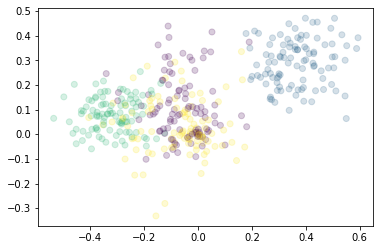

In [12]:
import matplotlib.pyplot as plt

plt.scatter(cur_data[0][:, 0], cur_data[0][:, 1], c=cur_labels[0], cmap='viridis', alpha=0.2)

In [9]:
cur_labels.flatten().unique(return_counts=True)

(tensor([0, 1, 2, 3]), tensor([100000, 100000, 100000, 100000]))

In [7]:
import torch
data = torch.rand(256, 400, 2).double()
manifold = geoopt.PoincareBall(c=1)



In [6]:
data.type()

'torch.FloatTensor'

In [17]:
manifold.weighted_midpoint(data,dim=0,reducedim=[1],keepdim=True).shape

torch.Size([256, 1, 2])

In [72]:
import geoopt
from geoopt.manifolds.stereographic.math import _lambda_x, _mobius_scalar_mul, _dist, _antipode, clamp_abs, drop_dims
from typing import List, Optional
def list_range(end: int):
    res: List[int] = []
    for d in range(end):
        res.append(d)
    return res
def _weighted_midpoint(
    xs: torch.Tensor,
    k: torch.Tensor,
    weights: Optional[torch.Tensor] = None,
    reducedim: Optional[List[int]] = None,
    dim: int = -1,
    keepdim: bool = False,
    lincomb: bool = False,
    posweight: bool = False,
):
    if reducedim is None:
        reducedim = list_range(xs.dim())
        reducedim.pop(dim)
    gamma = _lambda_x(xs, k=k, dim=dim, keepdim=True)
    if weights is None:
        weights = torch.tensor(1.0, dtype=xs.dtype, device=xs.device)
    else:
        weights = weights.unsqueeze(dim)
    if posweight and weights.lt(0).any():
        xs = torch.where(weights.lt(0), _antipode(xs, k=k, dim=dim), xs)
        weights = weights.abs()
    denominator = ((gamma - 1) * weights).sum(reducedim, keepdim=True)
    nominator = (gamma * weights * xs).sum(reducedim, keepdim=True)
    two_mean = nominator / clamp_abs(denominator, 1e-10)
    a_mean = _mobius_scalar_mul(
        torch.tensor(0.5, dtype=xs.dtype, device=xs.device), two_mean, k=k, dim=dim
    )
    if torch.any(k.gt(0)):
        # check antipode
        b_mean = _antipode(a_mean, k, dim=dim)
        a_dist = _dist(a_mean, xs, k=k, keepdim=True, dim=dim).sum(
            reducedim, keepdim=True
        )
        b_dist = _dist(b_mean, xs, k=k, keepdim=True, dim=dim).sum(
            reducedim, keepdim=True
        )
        better = k.gt(0) & (b_dist < a_dist)
        a_mean = torch.where(better, b_mean, a_mean)
    if lincomb:
        if weights.numel() == 1:
            alpha = weights.clone()
            for d in reducedim:
                alpha *= xs.size(d)
        else:
            weights, _ = torch.broadcast_tensors(weights, gamma)
            alpha = weights.sum(reducedim, keepdim=True)
        a_mean = _mobius_scalar_mul(alpha, a_mean, k=k, dim=dim)
    if not keepdim:
        a_mean = drop_dims(a_mean, reducedim)
    return a_mean

In [1]:
_weighted_midpoint(data,torch.tensor(-2).float(),dim=0).shape


NameError: name '_weighted_midpoint' is not defined